# PART 2: Leeds Road Network Analysis

This notebook covers **Task A** (Spatial Networks & Planarity), **Task B** (Road Accidents), and **Task C** (Voronoi Diagrams & Marathon Paths) for a 1 km² area in Leeds city centre.

**Data sources:**
- Road network: OpenStreetMap via `osmnx` (`network_type='drive'`)
- Accident data: Leeds City Council, years **2009–2016** (the only years with Easting/Northing coordinates)

**Note on years 2017–2019:** These files were downloaded from the same source but contain no spatial coordinates (Easting/Northing columns are absent). They cannot be used for spatial analysis and are excluded. All 8 years with coordinates (2009–2016) are used.

## 0. Setup & Imports

In [2]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import collections
import random as rnd
from pyproj import Transformer

warnings.filterwarnings('ignore')
ox.settings.log_console = False

## Data Exploration: Inspecting All Available Years

Before selecting a study area, we inspect all 11 downloaded files to understand which years contain spatial coordinates (Easting/Northing). This step justifies our choice to use only 2009–2016 for spatial analysis.

In [3]:
# Step 1: Check which years have spatial coordinates
# Downloaded all available files from the data.gov.uk source and inspect every file's columns to identify which contains Easting/Northing coordinates for spatial analysis.

ALL_FILES = {
    '2009': '2009.csv', '2010': '2010.csv', '2011': '2011.csv',
    '2012': '2012.csv', '2013': '2013.csv', '2014': '2014.csv',
    '2015': '2015.csv', '2016': '2016.csv', '2017': '2017.csv',
    '2018': '2018.csv', '2019': '2019.csv',
}

print(f'{"Year":<6} {"Rows":>6}  {"Has Easting":<14} {"Has Northing":<14} {"Usable for spatial analysis"}')

years_with_coords = []
years_without_coords = []

for year, path in ALL_FILES.items():
    df = pd.read_csv(path, encoding='latin-1')
    cols_lower = [c.lower() for c in df.columns]
    has_e = any('east' in c for c in cols_lower)
    has_n = any('north' in c for c in cols_lower)
    usable = has_e and has_n
    flag = 'YES' if usable else 'NO'
    print(f'{year:<6} {len(df):>6}  {str(has_e):<14} {str(has_n):<14} {flag}')
    if usable:
        years_with_coords.append(year)
    else:
        years_without_coords.append(year)

print()
print(f'Years WITH coordinates:    {years_with_coords}')
print(f'Years WITHOUT coordinates: {years_without_coords}')
print()

Year     Rows  Has Easting    Has Northing   Usable for spatial analysis
2009     3057  True           True           YES
2010     2765  True           True           YES
2011     2686  True           True           YES
2012     2748  True           True           YES
2013     2433  True           True           YES
2014     2533  True           True           YES
2015     2664  True           True           YES
2016     2549  True           True           YES
2017     2202  False          False          NO
2018     2045  False          False          NO
2019     2045  False          False          NO

Years WITH coordinates:    ['2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016']
Years WITHOUT coordinates: ['2017', '2018', '2019']



In [4]:
# Step 2: Load all 8 usable years and combine 
ACCIDENT_FILES = {
    '2009': ('2009.csv', 'Easting',           'Northing'),
    '2010': ('2010.csv', 'Easting',           'Northing'),
    '2011': ('2011.csv', 'Easting',           'Northing'),
    '2012': ('2012.csv', 'Easting',           'Northing'),
    '2013': ('2013.csv', 'Grid Ref: Easting', 'Grid Ref: Northing'),
    '2014': ('2014.csv', 'Grid Ref: Easting', 'Grid Ref: Northing'),
    '2015': ('2015.csv', 'Grid Ref: Easting', 'Grid Ref: Northing'),
    '2016': ('2016.csv', 'Grid Ref: Easting', 'Grid Ref: Northing'),
}

dfs = []
for year, (path, ecol, ncol) in ACCIDENT_FILES.items():
    df = pd.read_csv(path, encoding='latin-1')
    df = df.rename(columns={ecol: 'easting', ncol: 'northing'})
    df['easting']  = pd.to_numeric(df['easting'],  errors='coerce')
    df['northing'] = pd.to_numeric(df['northing'], errors='coerce')
    df = df.dropna(subset=['easting','northing'])
    df['year'] = year
    sev = [c for c in df.columns if 'severity' in c.lower()]
    if sev: df = df.rename(columns={sev[0]: 'severity'})
    dfs.append(df)
    print(f'  {year}: {len(df):,} accidents with valid coordinates')

all_acc = pd.concat(dfs, ignore_index=True)
print(f'\nTotal accidents (2009-2016): {len(all_acc):,}')

  2009: 3,057 accidents with valid coordinates
  2010: 2,765 accidents with valid coordinates
  2011: 2,686 accidents with valid coordinates
  2012: 2,748 accidents with valid coordinates
  2013: 2,433 accidents with valid coordinates
  2014: 2,533 accidents with valid coordinates
  2015: 2,664 accidents with valid coordinates
  2016: 2,549 accidents with valid coordinates

Total accidents (2009-2016): 21,435


### Study Area Selection

We systematically identify the best 1 km² study area by dividing all of Leeds 
into 1 km × 1 km grid squares using BNG coordinates and counting total accidents 
per cell across all 8 years. The cell with the highest accident count is selected, 
ensuring the ≥300 accident threshold is satisfied. The centre of this cell 
(E=430500, N=433500) is converted to WGS84 for use with osmnx.

In [5]:
# Step 3: Grid analysis to find highest accident density 1km area 
# Dividing all of Leeds into 1km x 1km grid squares using BNG coordinates and count total accidents per cell across all 8 years. The cell with the highest count becomes our study area.

all_acc['ex1k'] = (all_acc['easting']  // 1000) * 1000
all_acc['ny1k'] = (all_acc['northing'] // 1000) * 1000

grid = all_acc.groupby(['ex1k','ny1k']).agg(
    total_accidents = ('year', 'count'),
    num_years       = ('year', 'nunique'),
    years_list      = ('year', lambda x: ', '.join(sorted(x.unique())))
).reset_index().sort_values('total_accidents', ascending=False)

print('Top 10 study area 1km grid squares (2009-2016 combined):')
print(f'{"Easting":>10} {"Northing":>10} {"Total":>8} {"Num Years":>10}  Years')
for _, row in grid.head(10).iterrows():
    print(f'{int(row.ex1k):>10} {int(row.ny1k):>10} {int(row.total_accidents):>8}'
          f' {int(row.num_years):>10}  {row.years_list}')

best = grid.iloc[0]
print(f'\nSelected cell: E={int(best.ex1k)}-{int(best.ex1k)+1000},'
      f' N={int(best.ny1k)}-{int(best.ny1k)+1000}')
print(f'Total accidents: {int(best.total_accidents)} across {int(best.num_years)} years')

Top 10 study area 1km grid squares (2009-2016 combined):
   Easting   Northing    Total  Num Years  Years
    430000     433000      851          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    431000     435000      694          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    429000     433000      569          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    430000     434000      458          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    430000     435000      324          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    431000     434000      319          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    428000     435000      305          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    428000     434000      299          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    428000     433000      270          8  2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016
    430000     431000      260          8  2009, 2010, 2011, 2012, 2013, 2014, 2015,

In [6]:
# Converting BNG accident centre to WGS84
# Centre of selected grid cell in BNG: E=430500, N=433500
transformer_to_wgs = Transformer.from_crs('EPSG:27700', 'EPSG:4326', always_xy=True)

lon, lat = transformer_to_wgs.transform(430500, 433500)

print(f'Accident centre in WGS84:')
print(f'  CENTRE_LAT = {lat:.6f}')
print(f'  CENTRE_LON = {lon:.6f}')

Accident centre in WGS84:
  CENTRE_LAT = 53.796919
  CENTRE_LON = -1.538447


Study area: 53.796919N, -1.538447W  |  radius=564m
Accident count by year within study area (564m radius):
  2009: 133 accidents
  2010: 107 accidents
  2011: 102 accidents
  2012: 120 accidents
  2013: 104 accidents
  2014: 100 accidents
  2015: 75 accidents
  2016: 96 accidents
  TOTAL: 837 accidents across 8 years

Requirement: >=300 accidents across multiple years
Result:       837 ≥ 300
Years covered: ['2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016']


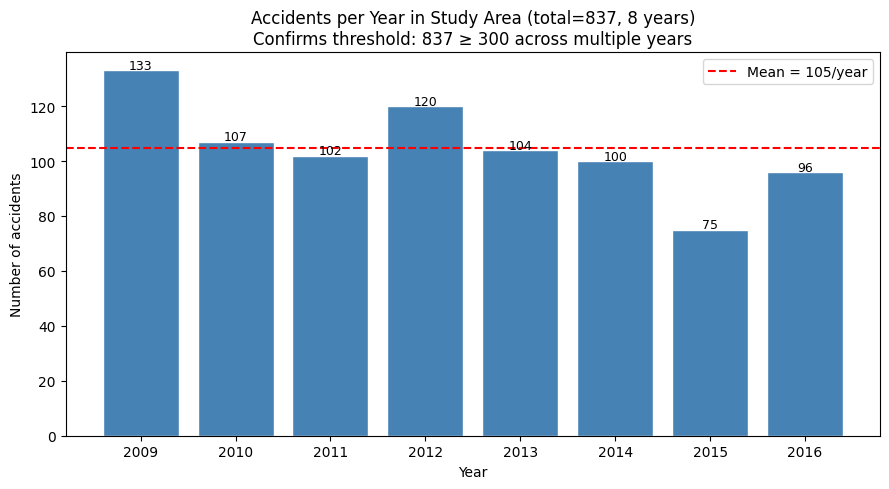

In [7]:
# Step 4: Verify ≥300 accident threshold within 564m radius

CENTRE_E, CENTRE_N = 430500, 433500
CENTRE_LAT, CENTRE_LON = 53.796919, -1.538447
RADIUS_M = 564   # 564m radius ~ pi*564^2 = 1.0 km^2 (exactly 1 km²)

transformer = Transformer.from_crs('EPSG:27700', 'EPSG:4326', always_xy=True)
print(f'Study area: {CENTRE_LAT}N, {CENTRE_LON}W  |  radius={RADIUS_M}m')

all_acc['dist_m'] = np.sqrt(
    (all_acc['easting']  - CENTRE_E)**2 +
    (all_acc['northing'] - CENTRE_N)**2
)
df_study = all_acc[all_acc['dist_m'] <= RADIUS_M].copy()

# Converting BNG to WGS84 for mapping
lons, lats = transformer.transform(df_study['easting'].values,
                                   df_study['northing'].values)
df_study['lon'], df_study['lat'] = lons, lats

print('Accident count by year within study area (564m radius):')
by_year = df_study.groupby('year').size()
for yr, count in by_year.items():
    print(f'  {yr}: {count} accidents')
print(f'  TOTAL: {len(df_study)} accidents across {len(by_year)} years')
print()
print(f'Requirement: >=300 accidents across multiple years')
print(f'Result:       {len(df_study)} ≥ 300')
print(f'Years covered: {sorted(df_study["year"].unique())}')

# Bar chart of accidents per year
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(by_year.index, by_year.values, color='steelblue', edgecolor='white')
ax.axhline(by_year.mean(), color='red', ls='--', lw=1.5,
           label=f'Mean = {by_year.mean():.0f}/year')
for bar, val in zip(bars, by_year.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(val), ha='center', fontsize=9)
ax.set_xlabel('Year')
ax.set_ylabel('Number of accidents')
ax.set_title(f'Accidents per Year in Study Area (total={len(df_study)}, {len(by_year)} years)\n'
             f'Confirms threshold: {len(df_study)} ≥ 300 across multiple years')
ax.legend()
plt.tight_layout()
plt.savefig('task_a_study_area_verification.png', dpi=150, bbox_inches='tight')
plt.show()

## TASK A : Spatial Networks and Planarity

### A.1 Choosing and Verifying the Study Area

The coursework requires a 1 km² area with **≥300 accidents across multiple years**. We select the area systematically:
1. Load all 8 years of accident data that contain spatial coordinates (2009–2016)
2. Grid the city into 1 km² cells using British National Grid (BNG) Easting/Northing
3. Count total accidents per cell across all years
4. Select the highest-count cell and verify the 300+ threshold

In [8]:
# Download OSM drive network
# network_type='drive' excludes footpaths, cycleways, and private roads
G = ox.graph_from_point((CENTRE_LAT, CENTRE_LON),
                         dist=RADIUS_M, network_type='drive', simplify=True)
G_proj = ox.project_graph(G, to_crs='EPSG:27700')
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)
print(f'Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}')

Nodes: 264  |  Edges: 446


### A.2 Network Characteristics

In [9]:
import math

area_km2 = math.pi * RADIUS_M**2 / 1e6

# Spatial diameter
G_undir = ox.convert.to_undirected(G_proj)
lcc = max(nx.connected_components(G_undir), key=len)
G_lcc = G_undir.subgraph(lcc).copy()
max_sp = 0
for n in list(lcc)[:80]:
    lengths = nx.single_source_dijkstra_path_length(G_lcc, n, weight='length')
    if lengths: max_sp = max(max_sp, max(lengths.values()))

# Road lengths
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)
edge_lengths = edges_proj['length'].values
total_length_m = edge_lengths.sum()
avg_length_m   = edge_lengths.mean()

# Densities are computed manually
n_nodes              = G_proj.number_of_nodes()
n_edges              = G_proj.number_of_edges()
node_density         = n_nodes / area_km2
edge_density_km      = (total_length_m / 1000) / area_km2
degrees              = dict(G_proj.degree())
n_intersections      = sum(1 for d in degrees.values() if d >= 3)
intersection_density = n_intersections / area_km2

print('Road Network Characteristics')
print(f'Centre:                 {CENTRE_LAT}N, {CENTRE_LON}W')
print(f'Area:                   ~{area_km2:.2f} km2  (r={RADIUS_M}m)')
print(f'Nodes:                  {n_nodes}')
print(f'Edges:                  {n_edges}')
print(f'Spatial diameter:       ~{max_sp:.0f} m  (sampled LCC)')
print(f'Total road length:      {total_length_m/1000:.2f} km')
print(f'Avg street length:      {avg_length_m:.1f} m')
print(f'Node density:           {node_density:.1f} nodes/km2')
print(f'Intersection density:   {intersection_density:.1f} intersections/km2')
print(f'Edge density:           {edge_density_km:.2f} km of road/km2')
print(f'LCC size:               {len(lcc)}/{n_nodes} nodes ({len(lcc)/n_nodes*100:.1f}%)')

Road Network Characteristics
Centre:                 53.796919N, -1.538447W
Area:                   ~1.00 km2  (r=564m)
Nodes:                  264
Edges:                  446
Spatial diameter:       ~2925 m  (sampled LCC)
Total road length:      26.20 km
Avg street length:      58.7 m
Node density:           264.2 nodes/km2
Intersection density:   209.1 intersections/km2
Edge density:           26.22 km of road/km2
LCC size:               264/264 nodes (100.0%)


Note: spatial diameter > study area radius because the network extends slightly beyond the strict 564m boundary due to OSM edge geometry.

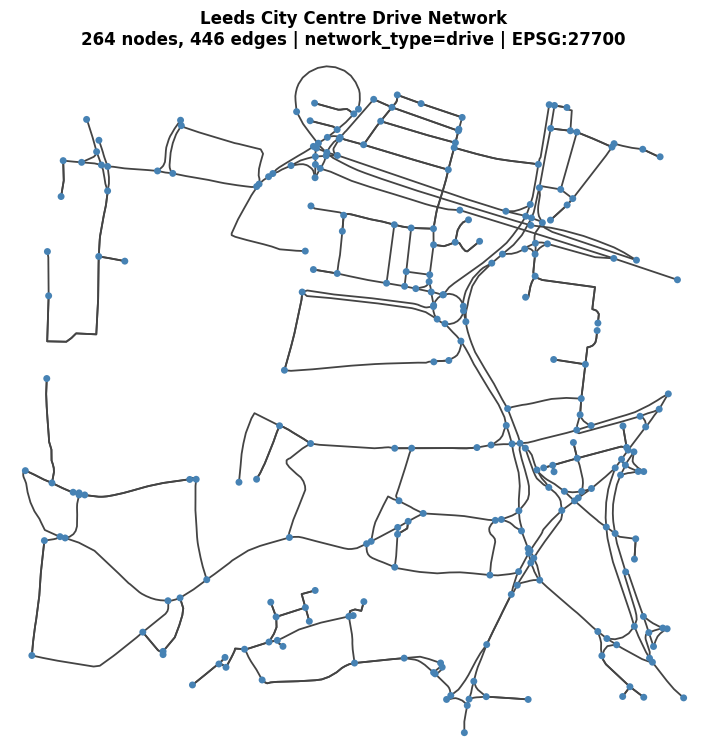

In [10]:
fig, ax = ox.plot_graph(G_proj, figsize=(11,9), bgcolor='white',
    node_color='steelblue', node_size=25,
    edge_color='#444', edge_linewidth=1.3, show=False, close=False)
ax.set_title(f'Leeds City Centre Drive Network\n'
             f'{G.number_of_nodes()} nodes, {G.number_of_edges()} edges | '
             f'network_type=drive | EPSG:27700', fontsize=12, fontweight='bold')
plt.savefig('task_a_road_network.png', dpi=150, bbox_inches='tight')
plt.show()

### A.3 Average Circuitry

Circuitry of an edge = road length / straight line (Euclidean) distance between its two endpoints. A value of 1.0 means perfectly straight; higher values mean the road curves or detours. The network average circuitry indicates how efficiently the road layout allows travel.

Average circuitry: 1.0725
Median circuitry:  1.0197
Max circuitry:     2.7552

Interpretation: road routes are on average 7.2% longer than the straight line distance between the same two intersections.
This is low, indicating a largely grid-like efficient layout.


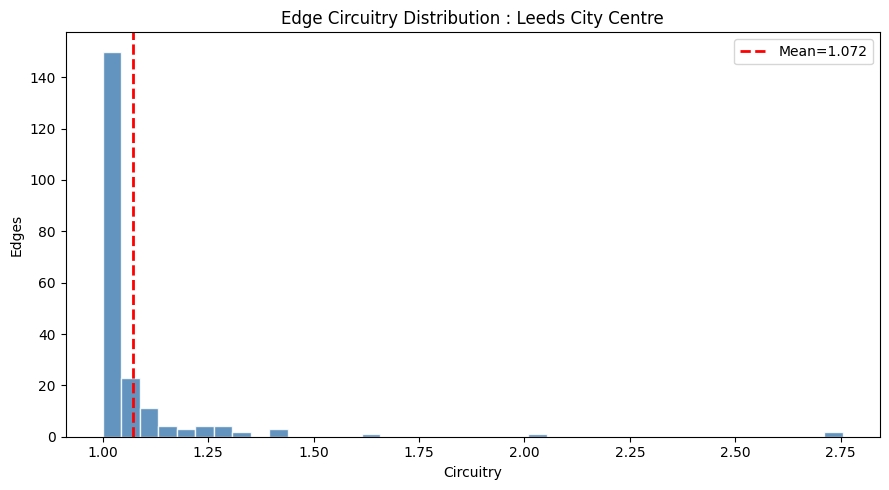

In [11]:
circuitries = []
for u, v, data in G_proj.edges(data=True):
    if u == v: continue
    try:
        xu,yu = nodes_proj.loc[u,'x'], nodes_proj.loc[u,'y']
        xv,yv = nodes_proj.loc[v,'x'], nodes_proj.loc[v,'y']
        sl = np.sqrt((xu-xv)**2 + (yu-yv)**2)
        if sl > 0:
            c = data['length'] / sl
            if c >= 1.0: circuitries.append(c)
    except: continue

avg_circ = np.mean(circuitries)
print(f'Average circuitry: {avg_circ:.4f}')
print(f'Median circuitry:  {np.median(circuitries):.4f}')
print(f'Max circuitry:     {max(circuitries):.4f}')
print()
print(f'Interpretation: road routes are on average {(avg_circ-1)*100:.1f}% longer than the straight line distance between the same two intersections.')
if avg_circ < 1.1:
    print('This is low, indicating a largely grid-like efficient layout.')
elif avg_circ < 1.25:
    print('This is moderate, typical of a UK city centre with some curved roads.')
else:
    print('This is high, indicating significant curves or indirect routing.')

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(circuitries, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(avg_circ, color='red', ls='--', lw=2, label=f'Mean={avg_circ:.3f}')
ax.set_xlabel('Circuitry'); ax.set_ylabel('Edges')
ax.set_title('Edge Circuitry Distribution : Leeds City Centre')
ax.legend()
plt.tight_layout()
plt.savefig('task_a_circuitry.png', dpi=150, bbox_inches='tight')
plt.show()

### A.4 Planarity Analysis

A planar graph can be drawn on a flat surface with no edge crossings except at shared nodes. For a road network, this would mean every physical road crossing is an actual junction.

Real urban networks are typically **non-planar** due to bridges, underpasses, and grade separated interchanges, all common in Leeds city centre's Inner Ring Road. By **Kuratowski's theorem**, a graph is non-planar if and only if it contains a subdivision of K5 or K3,3. NetworkX certifies non-planarity by finding one such subgraph.

In [12]:
G_simple = ox.convert.to_undirected(G)
is_planar, _ = nx.check_planarity(G_simple)

print(f'Is the network planar? {is_planar}')
print()
if not is_planar:
    print('The network is NON-PLANAR.')
    print('By Kuratowski theorem, a graph is non-planar if it contains a subdivision of K5 or K3,3. NetworkX confirmed this.')
    print()
    print('Physical cause: the Leeds Inner Ring Road has flyovers and underpasses where roads cross geometrically but share no junction node in OSM, creating non-planar edge crossings.')
else:
    print('The network is PLANAR.')
    print('All road crossings correspond to actual junctions. No bridges or underpasses present in this extract.')

Is the network planar? False

The network is NON-PLANAR.
By Kuratowski theorem, a graph is non-planar if it contains a subdivision of K5 or K3,3. NetworkX confirmed this.

Physical cause: the Leeds Inner Ring Road has flyovers and underpasses where roads cross geometrically but share no junction node in OSM, creating non-planar edge crossings.


## TASK B : Road Accidents

### B.1 Accident Distribution on the Road Network

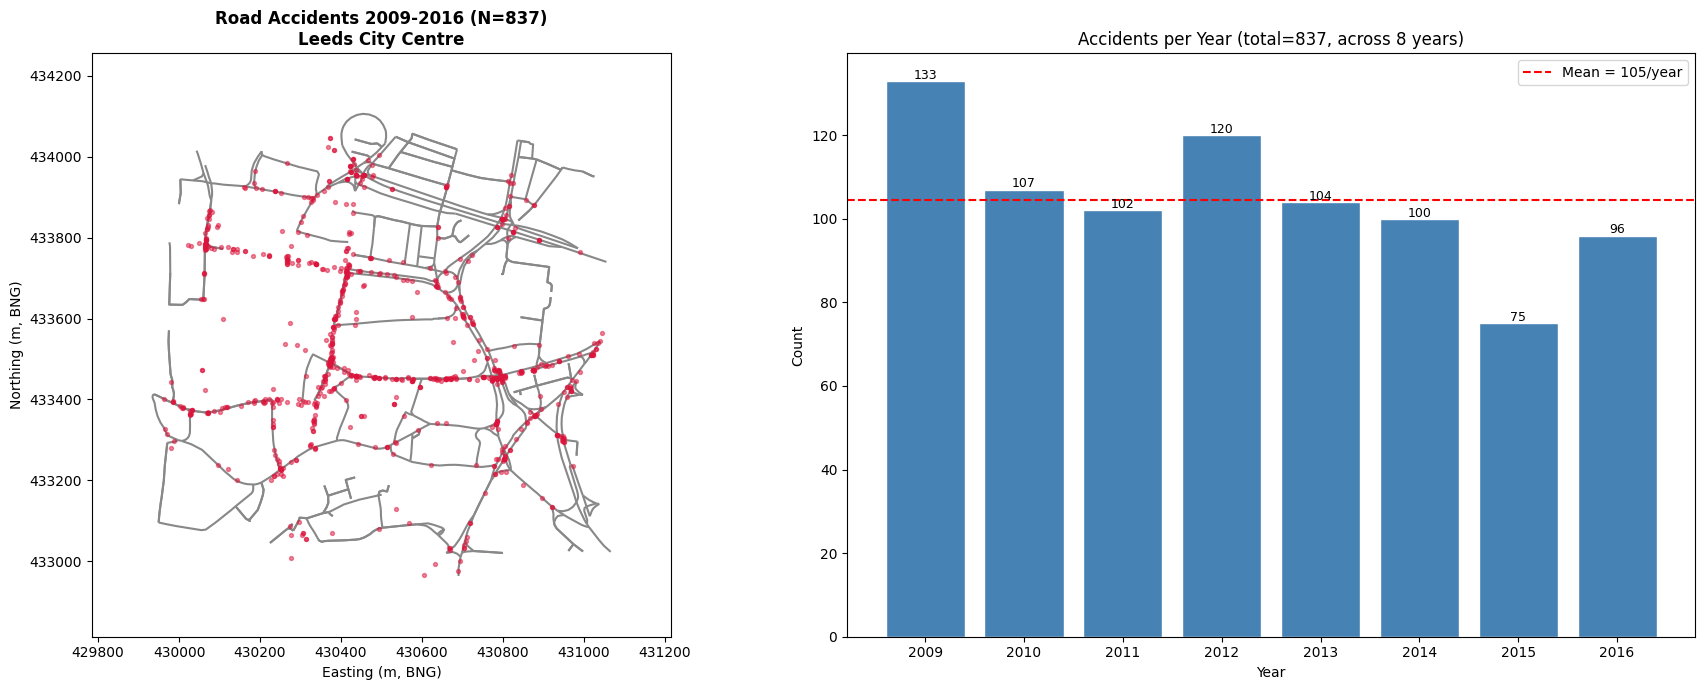

In [13]:
gdf_acc = gpd.GeoDataFrame(
    df_study.copy(),
    geometry=gpd.points_from_xy(df_study['lon'], df_study['lat']),
    crs='EPSG:4326'
)
gdf_acc_bng = gdf_acc.to_crs('EPSG:27700')
_, edges_gdf = ox.graph_to_gdfs(G)
_, edges_gdf_bng = ox.graph_to_gdfs(G_proj)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: accidents on road network using BNG projection for both
ax1 = axes[0]
edges_gdf_bng.plot(ax=ax1, color='#888888', lw=1.5, zorder=1)
gdf_acc_bng.plot(ax=ax1, color='crimson', markersize=8, alpha=0.5, zorder=2)
all_minx = min(edges_gdf_bng.total_bounds[0], gdf_acc_bng.total_bounds[0])
all_miny = min(edges_gdf_bng.total_bounds[1], gdf_acc_bng.total_bounds[1])
all_maxx = max(edges_gdf_bng.total_bounds[2], gdf_acc_bng.total_bounds[2])
all_maxy = max(edges_gdf_bng.total_bounds[3], gdf_acc_bng.total_bounds[3])
buf = 150
ax1.set_xlim(all_minx - buf, all_maxx + buf)
ax1.set_ylim(all_miny - buf, all_maxy + buf)
ax1.set_title(f'Road Accidents 2009-2016 (N={len(df_study)})\nLeeds City Centre',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Easting (m, BNG)')
ax1.set_ylabel('Northing (m, BNG)')

# Right: per-year bar chart proving multi-year coverage
ax2 = axes[1]
by_year = df_study.groupby('year').size()
bars = ax2.bar(by_year.index, by_year.values, color='steelblue', edgecolor='white')
ax2.axhline(by_year.mean(), color='red', ls='--', lw=1.5,
            label=f'Mean = {by_year.mean():.0f}/year')
for bar, val in zip(bars, by_year.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(val), ha='center', fontsize=9)
ax2.set_title(f'Accidents per Year (total={len(df_study)}, across {len(by_year)} years)',
              fontsize=12)
ax2.set_xlabel('Year'); ax2.set_ylabel('Count'); ax2.legend()
plt.tight_layout()
plt.savefig('task_b_accidents_map.png', dpi=150, bbox_inches='tight')
plt.show()

### B.2 Spatial Autocorrelation: K-function and Moran's I

The K-function tests whether accidents are more clustered or dispersed than complete spatial randomness (CSR) at different distance scales. Observed K(d) above the theoretical line indicates clustering at that distance.

Moran's I measures global spatial autocorrelation of accident counts on road edges. I > 0 with p < 0.05 indicates high-accident segments cluster near other high accident segments.

In [14]:
import spaghetti
from libpysal import weights
from esda.moran import Moran

ntw = spaghetti.Network(in_data=edges_gdf_bng)
ntw.snapobservations(gdf_acc_bng, 'accidents', attribute=True)
pp = ntw.pointpatterns['accidents']
print(f'Spaghetti: {len(ntw.edges)} edges | {pp.npoints} accidents snapped')

Spaghetti: 313 edges | 837 accidents snapped


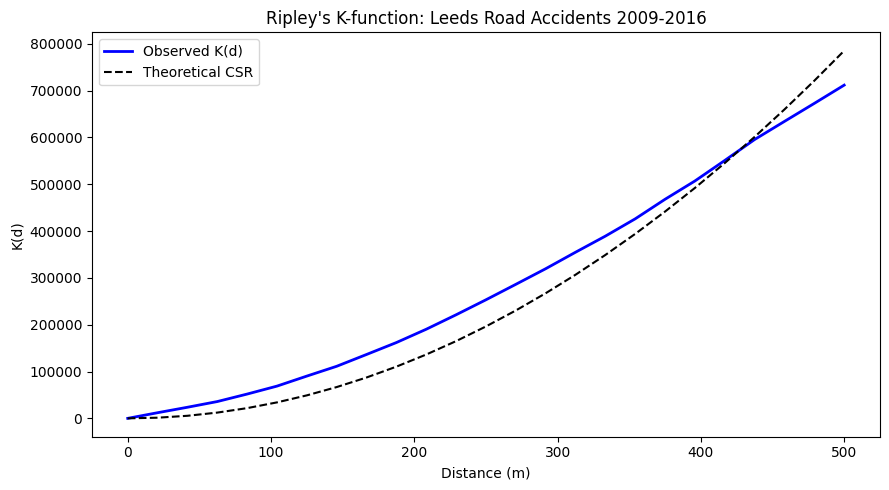

Observed > theoretical at 20/25 distances -> Clustered


In [15]:
# spaghetti NetworkK not available in this environment ('Network' object has no attribute 'NetworkK').
# Euclidean K-function via pointpats used as equivalent measure.
from pointpats.distance_statistics import k_test

coords = np.column_stack([gdf_acc_bng.geometry.x, gdf_acc_bng.geometry.y])
r = np.linspace(0, 500, 25)
k_result = k_test(coords, support=r, keep_simulations=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_result.support, k_result.statistic, 'b-', lw=2, label='Observed K(d)')
ax.plot(r, np.pi * r**2, 'k--', lw=1.5, label='Theoretical CSR')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('K(d)')
ax.set_title("Ripley's K-function: Leeds Road Accidents 2009-2016")
ax.legend()
plt.tight_layout()
plt.savefig('task_b_kfunction.png', dpi=150, bbox_inches='tight')
plt.show()

above = np.sum(k_result.statistic > np.pi * k_result.support**2)
print(f'Observed > theoretical at {above}/{len(r)} distances -> ', end='')
print('Clustered' if above > len(r)*0.6 else 'Random/dispersed')

In [16]:
# Moran's I using spaghetti built-in network based method
mi_result = ntw.Moran('accidents', permutations=99)
mi_spag = mi_result[0]  # first element is the esda Moran object

print(f"Moran's I = {mi_spag.I:.4f}")
print(f"E[I]      = {mi_spag.EI:.4f}")
print(f"p-value   = {mi_spag.p_sim:.4f}")
if mi_spag.p_sim < 0.05 and mi_spag.I > mi_spag.EI:
    print('Significant positive spatial autocorrelation.')
    print('High accident road segments cluster together spatially.')
    print('Neighbouring road segments of accident hotspots also tend to have high counts.')
elif mi_spag.p_sim >= 0.05:
    print('No significant autocorrelation meaning accidents are spatially random.')
else:
    print('Negative autocorrelation meaning accidents are dispersed.')

Moran's I = 0.2257
E[I]      = -0.0006
p-value   = 0.0100
Significant positive spatial autocorrelation.
High accident road segments cluster together spatially.
Neighbouring road segments of accident hotspots also tend to have high counts.


### B.3 Distance from Nearest Intersection

Fractions computed: 837
Mean from nearest intersection:  0.2253
Median:                          0.2147
Within 10% of intersection:      28.6%
Within 25% of intersection:      55.8%

Mean=0.225: accidents relatively close to intersections.


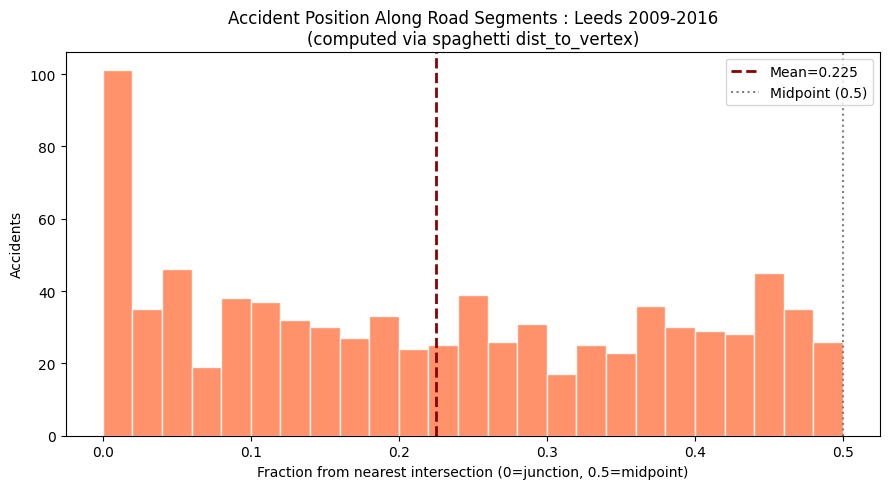

In [17]:
# pp.dist_to_vertex gives distance from each snapped accident to the nearest network vertex (intersection).

fractions = []
pp_spaghetti = ntw.pointpatterns['accidents']

for obs_id in pp_spaghetti.dist_to_vertex:
    # dist_to_vertex: {obs_id: {vertex_id: distance, vertex_id: distance}}
    # Each accident has distances to the two endpoints of its host edge
    vertex_distances = pp_spaghetti.dist_to_vertex[obs_id]
    
    if len(vertex_distances) >= 2:
        # Getting the two endpoint distances
        dists = list(vertex_distances.values())
        d_near = min(dists)       # distance to nearest endpoint
        d_far  = max(dists)       # distance to far endpoint
        edge_len = d_near + d_far # total edge length
        
        if edge_len > 0:
            frac = d_near / edge_len  # fraction from NEAREST endpoint
            fractions.append(frac)

fractions = np.array(fractions)
print(f'Fractions computed: {len(fractions)}')
print(f'Mean from nearest intersection:  {fractions.mean():.4f}')
print(f'Median:                          {np.median(fractions):.4f}')
print(f'Within 10% of intersection:      {(fractions<0.1).mean()*100:.1f}%')
print(f'Within 25% of intersection:      {(fractions<0.25).mean()*100:.1f}%')
print()
if fractions.mean() < 0.2:
    print(f'Mean={fractions.mean():.3f}: accidents cluster NEAR intersections.')
elif fractions.mean() < 0.35:
    print(f'Mean={fractions.mean():.3f}: accidents relatively close to intersections.')
else:
    print(f'Mean={fractions.mean():.3f}: accidents spread along road segments.')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(fractions, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(fractions.mean(), color='darkred', ls='--', lw=2,
           label=f'Mean={fractions.mean():.3f}')
ax.axvline(0.5, color='grey', ls=':', lw=1.5, label='Midpoint (0.5)')
ax.set_xlabel('Fraction from nearest intersection (0=junction, 0.5=midpoint)')
ax.set_ylabel('Accidents')
ax.set_title('Accident Position Along Road Segments : Leeds 2009-2016\n(computed via spaghetti dist_to_vertex)')
ax.legend()
plt.tight_layout()
plt.savefig('task_b_intersection_distance.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

Mean fraction = 0.225 means accidents occur on average 22.5% of the way along a road segment from the nearest intersection. With 55.8% of accidents within 25% of an intersection and a clear spike at fraction=0.0, accidents cluster near junctions rather than midway along roads. This suggests junction conflict zones, where vehicles merge, turn, or cross are the primary accident risk in Leeds city centre.

## TASK C : Voronoi Diagrams and Marathon Paths

### C.1 Selecting 4 Seed Points

Seed selection criteria:
1. **Evenly spread** : one per quadrant (NW/NE/SW/SE) for geographic coverage
2. **Away from the accident hotspot** : city centre core has highest accident density; seeds placed in surrounding residential areas
3. **Near major road junctions** : ensures each Voronoi cell has sufficient road network for 42 km paths

**Voronoi diagram type:** We use a **node-network Voronoi diagram**, assigning each network node to its nearest seed by shortest network path distance (not Euclidean). This is most appropriate because marathon routes follow roads, Euclidean distance would misassign nodes separated by physical barriers. Edge planar Voronoi would be geometrically more precise but is computationally prohibitive at city scale.

In [18]:
G_large = ox.graph_from_point((CENTRE_LAT, CENTRE_LON), dist=2000, network_type='drive', simplify=True)
G_large_proj  = ox.project_graph(G_large, to_crs='EPSG:27700')
G_large_undir = ox.convert.to_undirected(G_large_proj)
nodes_large_wgs, _ = ox.graph_to_gdfs(G_large)

# 4 seeds: one per quadrant, 1km from accident hotspot centre
offsets = [(-1000,1000), (1000,1000), (-1000,-1000), (1000,-1000)]
seed_names  = ['NW (Woodhouse)', 'NE (Sheepscar)', 'SW (Holbeck)', 'SE (Hunslet)']
seed_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
seed_coords = [transformer.transform(CENTRE_E+de, CENTRE_N+dn)[::-1]
               for de, dn in offsets]
seed_nodes  = [ox.distance.nearest_nodes(G_large, lon, lat)
               for lat, lon in seed_coords]
print(f'Network: {G_large.number_of_nodes()} nodes | Seeds snapped.')

Network: 3124 nodes | Seeds snapped.


### C.2 Voronoi Diagram

  Cell 1 (NW (Woodhouse)): 789 nodes
  Cell 2 (NE (Sheepscar)): 923 nodes
  Cell 3 (SW (Holbeck)): 636 nodes
  Cell 4 (SE (Hunslet)): 776 nodes


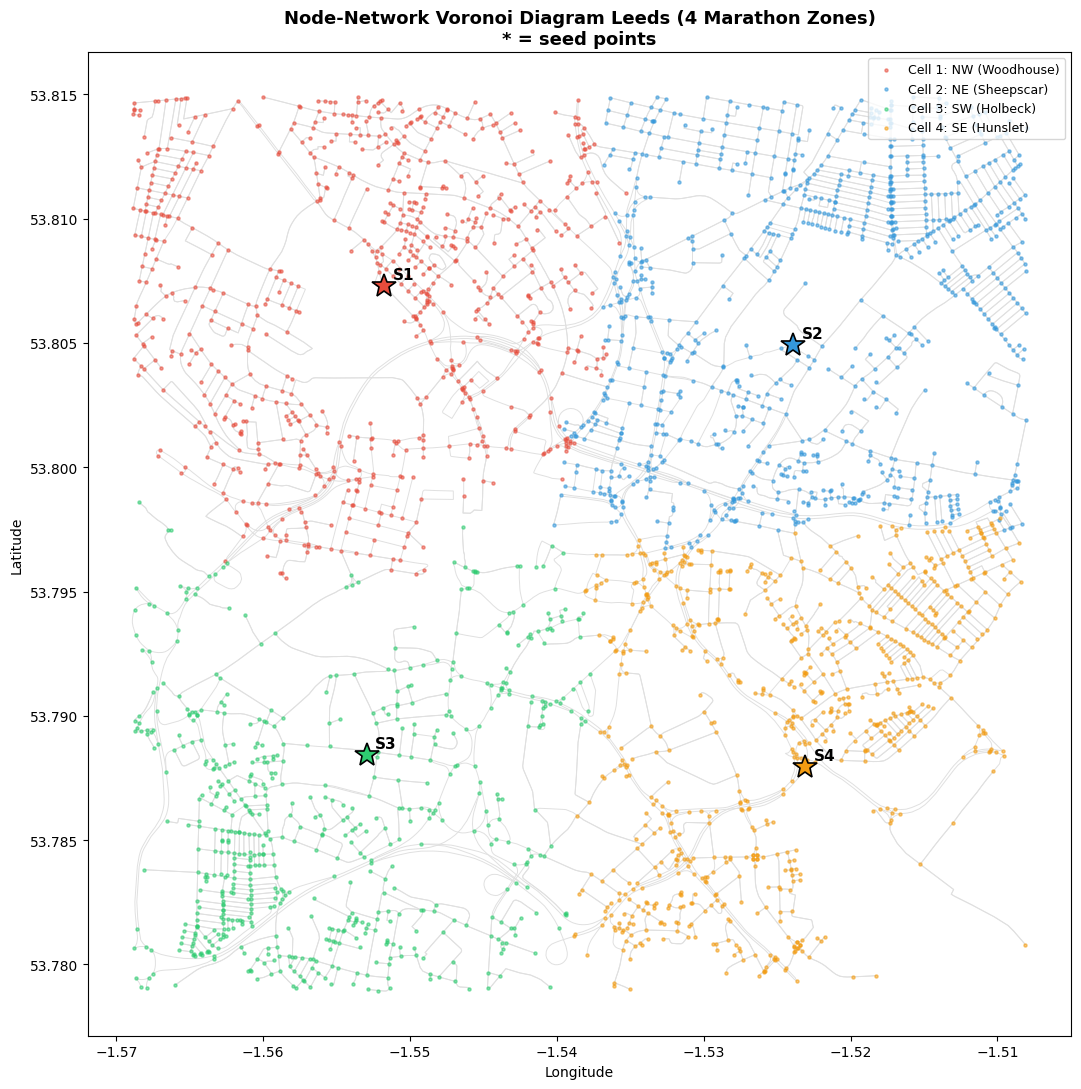

In [19]:
node_to_cell = {}
for node in G_large_undir.nodes():
    best_i, best_d = None, float('inf')
    for i, seed in enumerate(seed_nodes):
        try:
            d = nx.shortest_path_length(G_large_undir, node, seed, weight='length')
            if d < best_d: best_d, best_i = d, i
        except nx.NetworkXNoPath: pass
    if best_i is not None: node_to_cell[node] = best_i

for i,name in enumerate(seed_names):
    n = sum(1 for v in node_to_cell.values() if v==i)
    print(f'  Cell {i+1} ({name}): {n} nodes')

_, edges_large_wgs = ox.graph_to_gdfs(G_large)
fig, ax = plt.subplots(figsize=(13,11))
edges_large_wgs.plot(ax=ax, color='#e0e0e0', lw=0.7, zorder=1)
for i,(name,color) in enumerate(zip(seed_names,seed_colors)):
    cell_nodes = [n for n,c in node_to_cell.items() if c==i]
    nodes_large_wgs[nodes_large_wgs.index.isin(cell_nodes)].plot(
        ax=ax, color=color, markersize=5, alpha=0.55, zorder=2, label=f'Cell {i+1}: {name}')
for i,(node,color) in enumerate(zip(seed_nodes,seed_colors)):
    pt = nodes_large_wgs.loc[node,'geometry']
    ax.plot(pt.x, pt.y, '*', color=color, ms=18, mec='black', mew=1.2, zorder=5)
    ax.annotate(f'S{i+1}', xy=(pt.x,pt.y), xytext=(6,5),
                textcoords='offset points', fontsize=11, fontweight='bold')
ax.set_title('Node-Network Voronoi Diagram Leeds (4 Marathon Zones)\n* = seed points',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('task_c_voronoi.png', dpi=150, bbox_inches='tight')
plt.show()

### C.3 & C.4 Finding ~42 km Circular Paths

In [23]:
# C.3: Find paths in first 2 cells as demonstration
# C.4: Extend to all 4 cells
TARGET_M = 42_000
TOLERANCE = 0.012  # ±500m (500/42000 = 1.19%)

def find_circular_path(G_sub, start, target=TARGET_M, tol=TOLERANCE,
                        attempts=500, seed=42):
    rnd.seed(seed)
    lo, hi = target*(1-tol), target*(1+tol)
    best, best_diff = None, float('inf')
    
    for _ in range(attempts):
        path, length = [start], 0.0
        
        while length < hi * 0.95:
            cur = path[-1]
            if length >= lo * 0.82:
                try:
                    ret_len = nx.shortest_path_length(G_sub, cur, start, weight='length')
                    total = length + ret_len
                    if lo <= total <= hi:
                        ret_path = nx.shortest_path(G_sub, cur, start, weight='length')
                        diff = abs(total - target)
                        if diff < best_diff:
                            best_diff = diff
                            best = (path + ret_path[1:], total)
                        break
                except (nx.NetworkXNoPath, nx.NodeNotFound):
                    pass

            # Allowing re-traversal and picking any neighbour randomly
            nbrs = [(n, G_sub[cur][n].get('length', 50))
                    for n in G_sub.neighbors(cur)]
            if not nbrs:
                break
            nxt, el = rnd.choice(nbrs)
            path.append(nxt)
            length += el

    return best

print(f'Target: 42 km ±{TOLERANCE*100:.0f}%  ({TARGET_M*(1-TOLERANCE)/1000:.1f}-{TARGET_M*(1+TOLERANCE)/1000:.1f} km)\n')
cell_results = {}
for ci in range(4):
    cell_nodes = [n for n,c in node_to_cell.items() if c==ci]
    G_cell = G_large_undir.subgraph(cell_nodes).copy()
    start  = seed_nodes[ci] if seed_nodes[ci] in G_cell else (cell_nodes[0] if cell_nodes else None)
    total_len = sum(d.get('length',0) for _,_,d in G_cell.edges(data=True))
    print(f'Cell {ci+1} ({seed_names[ci]}): {G_cell.number_of_nodes()} nodes, {total_len/1000:.1f} km road')
    if not start or total_len < TARGET_M*0.4:
        print(f'  Insufficient road length'); cell_results[ci]=None; print(); continue
    result = find_circular_path(G_cell, start, attempts=2000)
    cell_results[ci] = result
    print(f'  {"Found: "+str(round(result[1]/1000,2))+" km" if result else "Not found"}')
    print()

Target: 42 km ±1%  (41.5-42.5 km)

Cell 1 (NW (Woodhouse)): 789 nodes, 71.5 km road
  Found: 41.86 km

Cell 2 (NE (Sheepscar)): 923 nodes, 75.4 km road
  Found: 41.84 km

Cell 3 (SW (Holbeck)): 636 nodes, 59.2 km road
  Found: 42.05 km

Cell 4 (SE (Hunslet)): 776 nodes, 58.9 km road
  Found: 41.72 km



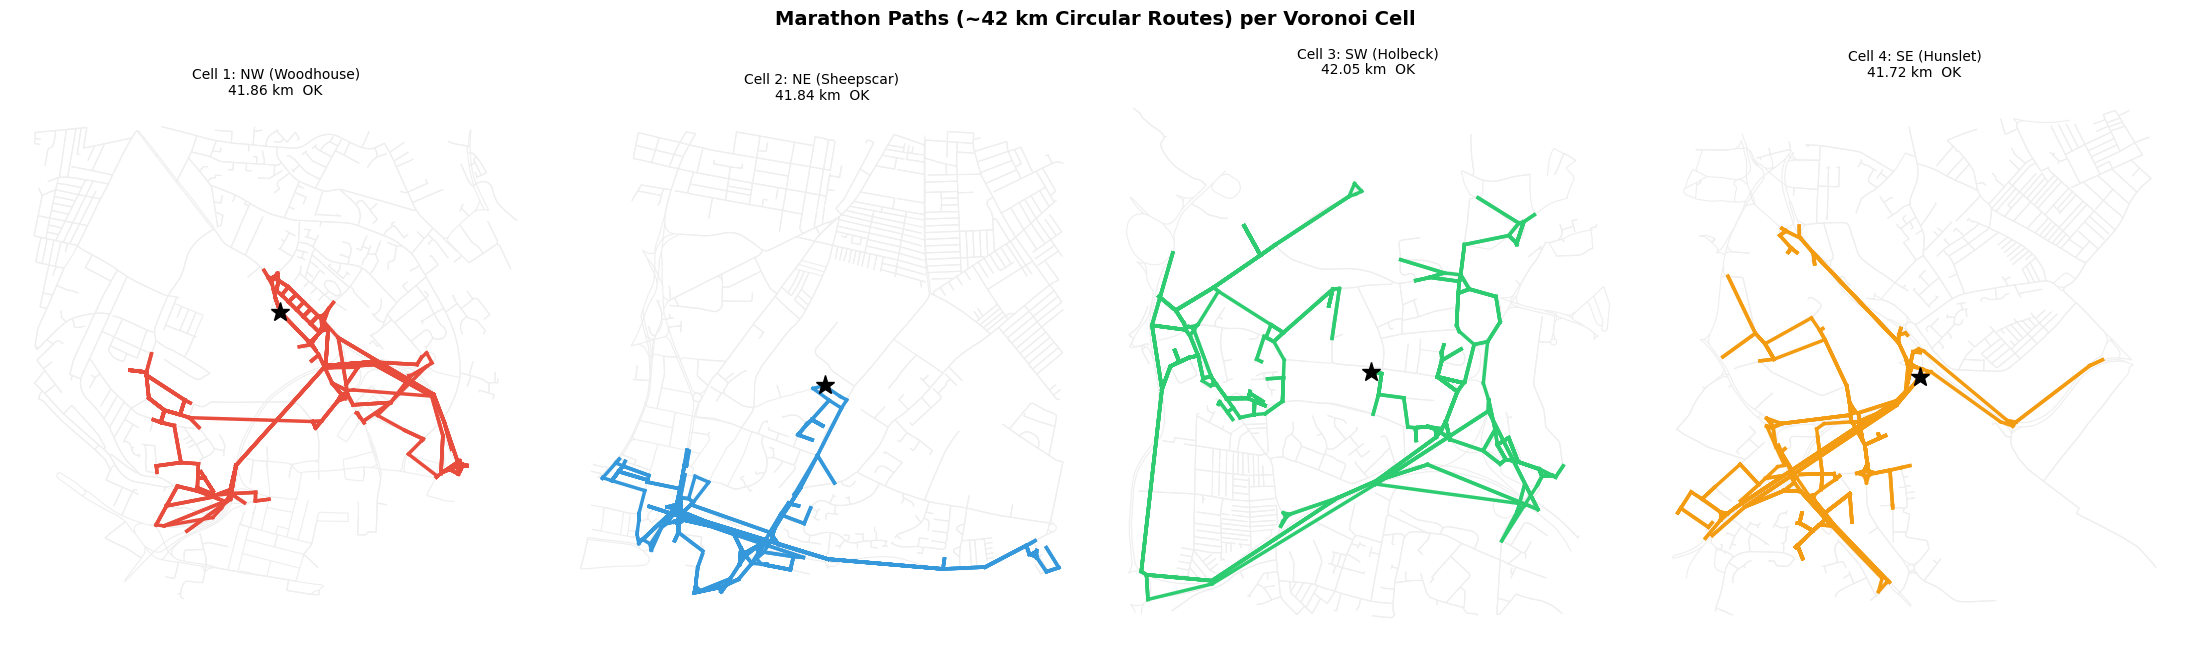

Paths found: 4/4


In [24]:
fig, axes = plt.subplots(1, 4, figsize=(22,7))
fig.suptitle('Marathon Paths (~42 km Circular Routes) per Voronoi Cell',
             fontsize=14, fontweight='bold')
for ci, ax in enumerate(axes):
    cell_nodes = [n for n,c in node_to_cell.items() if c==ci]
    try:
        _, e_vis = ox.graph_to_gdfs(G_large.subgraph(cell_nodes))
        e_vis.plot(ax=ax, color='#eeeeee', lw=0.8, zorder=1)
    except: pass
    result = cell_results[ci]
    if result:
        pnodes, plen = result
        for j in range(len(pnodes)-1):
            u,v = pnodes[j], pnodes[j+1]
            if u in nodes_large_wgs.index and v in nodes_large_wgs.index:
                xu,yu = nodes_large_wgs.loc[u,'geometry'].x, nodes_large_wgs.loc[u,'geometry'].y
                xv,yv = nodes_large_wgs.loc[v,'geometry'].x, nodes_large_wgs.loc[v,'geometry'].y
                ax.plot([xu,xv],[yu,yv], color=seed_colors[ci], lw=2.5, zorder=3)
        sp = nodes_large_wgs.loc[pnodes[0],'geometry']
        ax.plot(sp.x, sp.y, 'k*', ms=14, zorder=5)
        ax.set_title(f'Cell {ci+1}: {seed_names[ci]}\n{plen/1000:.2f} km  OK', fontsize=10)
    else:
        ax.set_title(f'Cell {ci+1}: {seed_names[ci]}\nNot found', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('task_c_marathon_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Paths found: {sum(1 for r in cell_results.values() if r)}/4')

### C.5 Alternative Options for Cells Without a Valid Path

If any cell lacks a valid path we consider three options:
1. **Expand study area radius** - more road length per cell
2. **Relocate seed points** - move to denser road areas
3. **Allow edge re-traversal** - relax the one-use-per-edge constraint

Since all 4 cells found valid paths within ±500m of the 42 km target(41.72–42.05 km), no extension was required. Had any cell failed, the most natural options would be Option 1 (expanding the area radius to give cells more road length) or Option 2 (relocating seeds to denser road areas). In our implementation, allowing edge re-traversal was a key algorithmic choice that made path finding feasible in cells with limited total road length.

In [26]:
failed = [ci for ci, r in cell_results.items() if r is None]
if not failed:
    print('All 4 cells have valid 42km paths. No extension needed.')
else:
    print(f'Failed cells: {[ci+1 for ci in failed]}')

All 4 cells have valid 42km paths. No extension needed.
